In [1]:
import matplotlib.pyplot as plt

from classes.Dashboard import Dashboard
from classes.DataManager import DataManager
from classes.ExperimentRunner import ExperimentRunner
from classes.PlotFactory import PlotFactory
from classes.TradingStrategy import TradingStrategy
from classes.models.HyperparamConfig import HyperparamConfig
%load_ext autoreload
%autoreload 2

import torch
from classes.models.ExperimentConfig import ExperimentConfig
import panel as pn

pn.extension('tabulator', design="material")

In [2]:
import os
import random
import numpy as np
import torch

def set_global_seed(seed: int) -> None:
    # Python
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Make CuDNN deterministic (IMPORTANT for LSTM)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# 1. Preparation

## 1.1 Setup Experiment Configuration

In [3]:
exp_config = ExperimentConfig(
    target="Close_NDX",
    file_path="data/NDX_data.csv",
)

## 1.2 Activate GPU usage

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


3223 4028
2017-11-10 2021-01-26


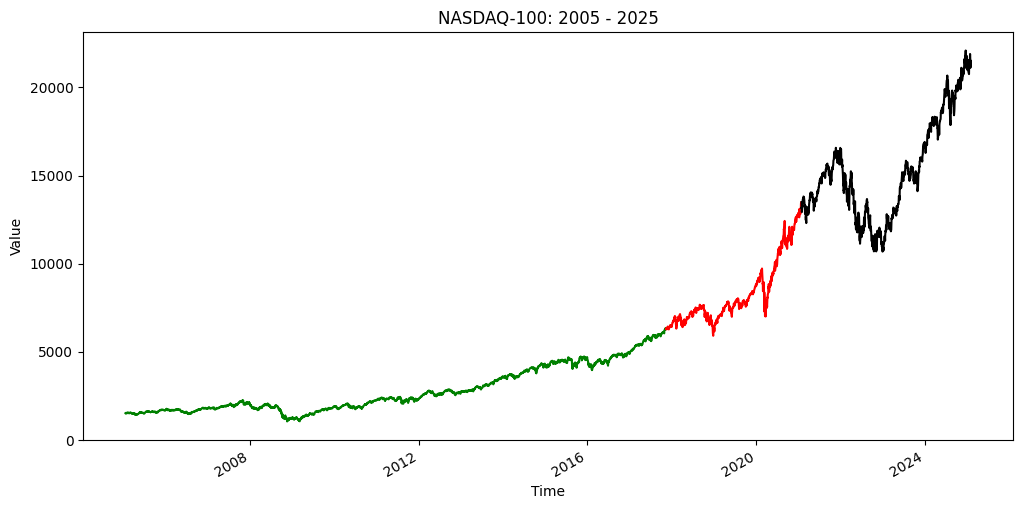

In [12]:
dm = DataManager(exp_config)
data = dm.load_data()
target = data[exp_config.target]

PlotFactory.plot_data(target)

# 2. Dashboard

In [6]:
features = dm.get_columns()
dashboard = Dashboard(features, exp_config)
dashboard.build_dashboard()

Column(design=<class 'panel.theme.materi...)
    [0] Row(design=<class 'panel.theme.materi...)
        [0] Card(design=<class 'panel.theme.materi..., title='Dataset')
            [0] Markdown(str, design=<class 'panel.theme.materi...)
            [1] CheckBoxGroup(design=<class 'panel.theme.materi..., name='Training Features', options=['Close_DX-Y.NYB', ...], value=['Close_NDX'])
        [1] Card(design=<class 'panel.theme.materi..., title='Experiment Grid')
            [0] Markdown(str, design=<class 'panel.theme.materi...)
            [1] Row(design=<class 'panel.theme.materi...)
                [0] MultiChoice(design=<class 'panel.theme.materi..., name='window_size grid', options=[1, 5, 10, 20, ...], value=[30])
                [1] MultiChoice(design=<class 'panel.theme.materi..., name='horizon', options=[1, 5, 10, 30, 90], value=[1])
            [2] Row(design=<class 'panel.theme.materi...)
                [0] MultiChoice(design=<class 'panel.theme.materi..., name='batch_size grid', options=[8, 16, 32, 64], value=[16])
                [1] MultiChoice(design=<class 'panel.theme.materi..., name='patience grid', options=[5, 10, 50], value=[10])
            [3] Row(design=<class 'panel.theme.materi...)
                [0] MultiChoice(design=<class 'panel.theme.materi..., name='hidden_size grid', options=[10, 30, 50, 100, ...], value=[50])
                [1] MultiChoice(design=<class 'panel.theme.materi..., name='num_layers grid', options=[1, 2, 3, 4], value=[1])
            [4] Row(design=<class 'panel.theme.materi...)
                [0] MultiChoice(design=<class 'panel.theme.materi..., name='dropout grid', options=[0.0, 0.1, 0.2, 0.3], value=[0.0, 0.1])
                [1] MultiChoice(design=<class 'panel.theme.materi..., name='lr grid', options=[0.01, 0.001, ...], value=[0.001, 0.0001])
            [5] Row(design=<class 'panel.theme.materi...)
                [0] MultiChoice(design=<class 'panel.theme.materi..., name='optimizer grid', options=['Adam', 'NAdam', ...], value=['Adam'])
            [6] Divider(design=<class 'panel.theme.materi...)
            [7] Row(design=<class 'panel.theme.materi...)
                [0] IntInput(design=<class 'panel.theme.materi..., end=50, name='Number of seeds (..., start=1, value=1)
                [1] IntInput(design=<class 'panel.theme.materi..., end=10000, name='max_epochs', start=10, step=50, value=250)
            [8] Divider(design=<class 'panel.theme.materi...)
            [9] Row(design=<class 'panel.theme.materi...)
                [0] TextInput(design=<class 'panel.theme.materi..., name='runs output dir', value='runs/Close_NDX/2026-02-17...)
                [1] Checkbox(design=<class 'panel.theme.materi..., name='Save plots per run', value=True)
                [2] Checkbox(design=<class 'panel.theme.materi..., name='Also save unscaled p..., value=True)
    [1] Row(design=<class 'panel.theme.materi...)
        [0] TextInput(design=<class 'panel.theme.materi..., name='results root', value='run/')
        [1] Button(button_type='primary', design=<class 'panel.theme.materi..., name='Refresh Results')
    [2] Column(design=<class 'panel.theme.materi...)
        [0] Markdown(str, design=<class 'panel.theme.materi...)
        [1] Tabulator(design=<class 'panel.theme.materi..., height=300, page_size=20, pagination='local', value=              ...)
        [2] Tabulator(design=<class 'panel.theme.materi..., height=250, page_size=10, pagination='local', value=              ...)

# 3. Train Hyperparams

In [ ]:
import matplotlib.pyplot as plt
print(dashboard.w_features.value)
dashboard_params = dashboard.get_values()
print(dashboard_params)

if not dashboard_params.features:
    raise ValueError("No features selected")

exp_runner = ExperimentRunner(exp_config, device)
exp_runner.prepare(dashboard_params)

exp_runner.data_manager.prepare(exp_runner.hyperparam_configs[0].features)
data = exp_runner.data_manager.scaled_data
plt.plot(data)

In [45]:
exp_runner.run_grid_search()

Running experiment: HyperparamConfig(features=['Close_DX-Y.NYB', 'Close_NDX', 'Volume_NDX', 'MACD_NDX', 'RSI_NDX', 'ATR_NDX', 'MACRO_cpi', 'MACRO_rate', 'MACRO_ppi', 'Close_VIX', 'MACRO_gdp', 'MACRO_unrate', 'MACRO_CSI', 'MACRO_HS'], window_size=5, horizon=1, batch_size=32, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


Early stopping at epoch 134
Best validation loss: 0.004077 at epoch 124


In [47]:
results = exp_runner.train_and_evaluate_best_feature_sets()

Running experiment: HyperparamConfig(features=['Close_NDX'], window_size=5, horizon=1, batch_size=32, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


Early stopping at epoch 35
Best validation loss: 0.000078 at epoch 25
Running experiment: HyperparamConfig(features=['Close_NDX', 'Close_DX-Y.NYB'], window_size=5, horizon=1, batch_size=32, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


Early stopping at epoch 40
Best validation loss: 0.000068 at epoch 30
Running experiment: HyperparamConfig(features=['Close_NDX', 'Volume_NDX'], window_size=5, horizon=1, batch_size=32, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


Early stopping at epoch 74
Best validation loss: 0.000069 at epoch 64
Running experiment: HyperparamConfig(features=['Close_NDX', 'MACD_NDX'], window_size=5, horizon=1, batch_size=32, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


Early stopping at epoch 40
Best validation loss: 0.000504 at epoch 30
Running experiment: HyperparamConfig(features=['Close_NDX', 'RSI_NDX'], window_size=5, horizon=1, batch_size=32, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


...

Early stopping at epoch 99
Best validation loss: 0.000291 at epoch 89
Running experiment: HyperparamConfig(features=['Close_NDX', 'MACRO_unrate'], window_size=5, horizon=1, batch_size=32, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


Early stopping at epoch 42
Best validation loss: 0.000303 at epoch 32
Running experiment: HyperparamConfig(features=['Close_NDX', 'MACRO_CSI'], window_size=5, horizon=1, batch_size=32, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


Early stopping at epoch 47
Best validation loss: 0.000126 at epoch 37
Running experiment: HyperparamConfig(features=['Close_NDX', 'MACRO_HS'], window_size=5, horizon=1, batch_size=32, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


Early stopping at epoch 32
Best validation loss: 0.000096 at epoch 22
Running experiment: HyperparamConfig(features=['Close_NDX', 'Close_DX-Y.NYB', 'Volume_NDX', 'MACD_NDX', 'RSI_NDX', 'ATR_NDX', 'MACRO_cpi', 'MACRO_rate', 'MACRO_ppi', 'Close_VIX', 'MACRO_gdp', 'MACRO_unrate', 'MACRO_CSI', 'MACRO_HS'], window_size=5, horizon=1, batch_size=32, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


Early stopping at epoch 11
Best validation loss: 0.027035 at epoch 1


{'loss': 0.00030783709574579924, 'mae': 275.05180105022777, 'rmse': 358.3804222063603, 'r2': 0.9830357096063577, 'directional_accuracy': 0.42714570858283435, 'naive_rmse': 188.1067152364447, 'n_samples': 1003, 'scale': 'unscaled', 'loss_scale': 'scaled'}


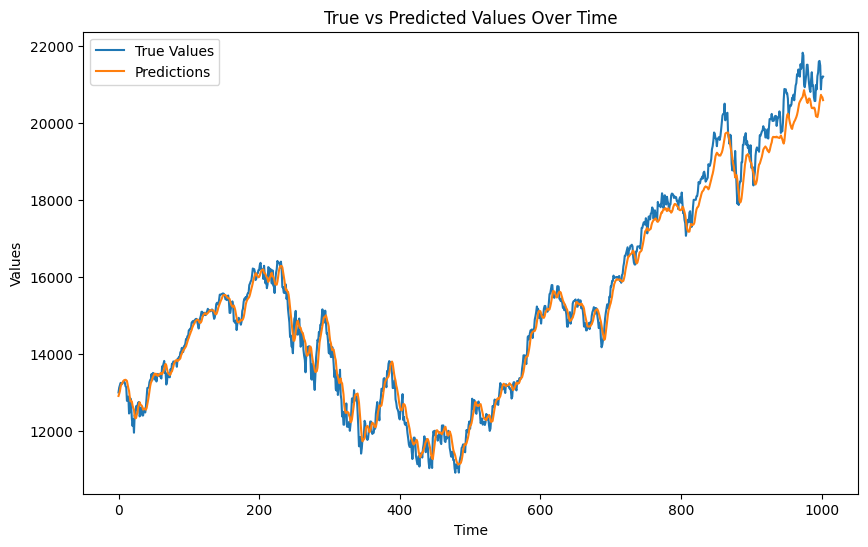

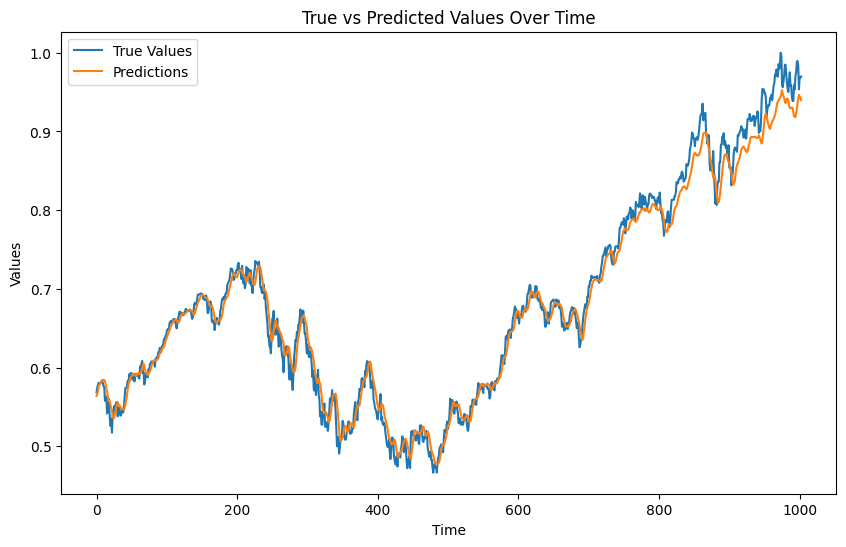

C:\Users\User\PycharmProjects\LSTMPrediction\classes\ExperimentRunner.py:731: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_agg, data_agg, feature_names=feature_names, show=False)


In [49]:
exp_runner.evaluate_best_model()

In [48]:
exp_runner.best_hyperparam_config

HyperparamConfig(features=['Close_NDX', 'Close_VIX'], window_size=5, horizon=1, batch_size=32, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)

In [16]:
# Rerun the following cells with best models and rename folders

exp_runner = ExperimentRunner(exp_config, device)
path = "run/final/best_run_one_feature/"
checkpoint_path = path + "checkpoint.pt"
config_path = path + "config.json"

exp_runner.load_model(checkpoint_path, config_path)

In [ ]:
exp_runner.evaluate_best_model()

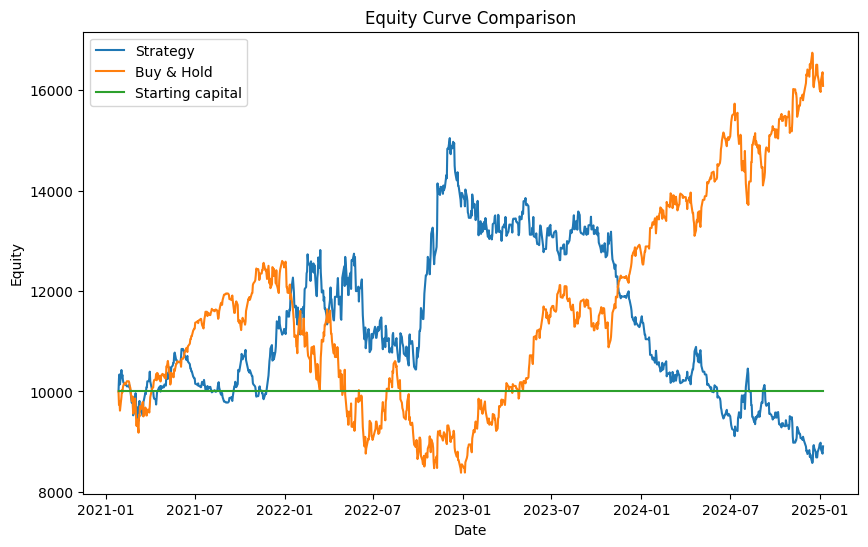

,date,price,predicted,position,strategy_return,equity
0,2021-01-26,13033.995960,12867.278418,-1.0,0.026485,10000.000000
1,2021-01-27,12688.792360,12951.697665,1.0,0.007158,10264.848632
2,2021-01-28,12779.620760,12933.367199,1.0,-0.019078,10338.326056
3,2021-01-29,12535.807160,12904.573660,1.0,0.028124,10141.088240
4,2021-02-01,12888.362410,12842.770429,-1.0,-0.013569,10426.294757
...,...,...,...,...,...,...
989,2024-12-31,20875.178251,20366.060755,-1.0,0.003393,8948.616766
990,2025-01-02,20804.343451,20321.275540,-1.0,-0.015295,8978.981703
991,2025-01-03,21122.547051,20208.126063,-1.0,-0.009157,8841.647675
992,2025-01-06,21315.966551,20125.024135,-1.0,0.016613,8760.684566


In [17]:
exp_runner.simulate_trading("2021-01-26", "2025-01-07", 10000, TradingStrategy.prediction_direction())